In [62]:
###!/usr/bin/env python
################################################
# New style 
# ###############################################
import sys
import os

rootdir_ = '../'
if ( rootdir_ not in sys.path ):
    sys.path.append(rootdir_)
    print( f" a path to {rootdir_} added in {__name__} ")


from Utils import GridUtils as GrU
from Utils import utils as uti
from Utils import MyConstants as Co
from Utils import time_utils as tuti
from Utils import numerical_utils as nuti

import analysis_utils as auti


#from PyRegridding.Utils import MakePressures as MkP
#from Drivers import RegridField as RgF
import RegridField as RgF

# The usual
from datetime import date
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# for smoothing , nonlienar colors ...
from scipy.ndimage import uniform_filter
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors

# Some other useful packages 
import copy
import time
import cftime
import yaml
import numbers

# Some other useful packages 
import importlib
from pathlib import Path


importlib.reload( auti )

Rdair=Co.Rdair()


In [2]:
def make_rho( X ):
    te = X.T.values
    pint=X.PINT.values
    nt,nz,ny,nx = np.shape( te )
    pmid = 0.5*( pint[:,0:nz,:,:] + pint[:,1:nz+1,:,:] )
    te_int = np.zeros( (nt,nz+1,ny,nx) )
    te_int[:,0,:]=te[:,0,:,:]
    te_int[:,nz,:]=te[:,nz-1,:,:]
    for z in np.arange( start=1,stop=nz ):
        te_int[:,z,:] = 0.5*( te[:,z-1,:] + te[:,z,:] )
    rho = pint / (Rdair * te_int )

    return rho


In [3]:
year,month,day,hour=2004,8,1,0
nsteps= 31*4
dates=[f"{year:04d}-{month:02d}-{day:02d}-{hour*3_600:05d}"]
for n in np.arange( nsteps ):
    year,month,day,hour = tuti.increment_hours( [year,month,day,hour], nhours=6 )
    date_=f"{year:04d}-{month:02d}-{day:02d}-{hour*3_600:05d}"
    #print( date_ )
    dates.append( date_ )


In [4]:

"""
case1 = 'cam77_dyamond1_prod1'
base1=f'/glade/derecho/scratch/juliob/archive/{case1}/atm/hist/DynVars_dyamond_fv1x1'
case2 = 'c124_dyamond1_prod2'
base2=f'/glade/derecho/scratch/juliob/archive/{case2}/atm/hist/DynVars_dyamond_fv1x1'
"""
files1,files2 = [] , []
case1 = 'c153_topfix_ne240pg3_FMTHIST_xic_x02'
base1=f'/glade/derecho/scratch/juliob/archive/{case1}/atm/fv1x1/{case1}.cam.h1i'

for date in dates:
    f1 = f'{base1}.{date}.nc'
    files1.append( f1 )
    #f2 = f'{base2}.{date}.nc'
    #files2.append( f2 )



In [5]:
%%time
#X2=xr.open_mfdataset( files2 ,  data_vars='different', coords='different', compat='no_conflicts'   )

X1=xr.open_mfdataset( files1 ,  data_vars='different', coords='different', compat='no_conflicts'   )


CPU times: user 4.08 s, sys: 733 ms, total: 4.81 s
Wall time: 8.7 s


In [6]:
###########################################
# Grid info and topo 
###########################################

grav=Co.grav()
plev=X1.lev.values
lat=X1.lat.values
lon=X1.lon.values

zlev=-7_000. * np.log( plev / 1_000. )

reso='14km'

ftopo='/glade/work/juliob/Topo/NCARTopoJTB/cases/fv1x1_Sco100_GrnlAnt/output/fv1x1_gmted2010_modis_bedmachine_nc3000_Laplace0100_noleak_greenlndantarcsgh30fac2.50_20251009.nc'
Topo=xr.open_dataset( ftopo )
htopo=Topo.PHIS.values/grav


######################################################
#   - MPAS derived fluxes are not scaled by density.
#   - They are on MPAS interface heights given by zgrid
#
#   - CAM-SE ne240 derived fluxes are scaled by a 
#     stupid 'proxy' density RhoProxy(lev) (in files)
#   - They are on CAM's layer midlevels PMID
#=====================================================
#
# For clear apples to apples comparison ... it might be 
# good to interpolate to a fixed pressure ... maybe 2500 Pa.
# and then scale by rho = P_2500 / (R_dair * T_2500)


if ('upwp' in X1):
    upwp_1 = X1.upwp.values 
elif ('Upwp' in X1):
    upwp_1 = X1.Upwp.values 

if ('vpwp' in X1):
    vpwp_1 = X1.vpwp.values 
elif ('Vpwp' in X1):
    vpwp_1 = X1.Vpwp.values 


u_1 = X1.U.values 
v_1 = X1.V.values



#vpwp = X.vpwp.values


epwp_1 = np.sqrt( upwp_1**2 + vpwp_1**2 )
rho1=1.0 # make_rho( X1 )
rho_epwp_1 = rho1 * epwp_1


nt,nz,ny,nx = np.shape( u_1 )
zeta_1 = np.zeros( ( nt,nz,ny,nx) )

for t in np.arange( nt ):
    for z in np.arange( nz ):
        zeta_1[t,z,:,:] = nuti.Sphere_Curl2( f_x=u_1[t,z,:,:]  , f_y=v_1[t,z,:,:] , lat=lat, lon=lon , wrap=True, verbose=False)


[1.0e-05 2.0e-05 5.0e-05 1.0e-04 1.5e-04 2.0e-04 3.0e-04 4.0e-04 5.0e-04
 6.0e-04 8.0e-04 1.0e-03 1.5e-03 2.0e-03 3.0e-03 4.0e-03 5.0e-03 6.0e-03
 1.0e-02 2.0e-02 5.0e-02 1.0e-01]
38.09935214868368
22872.906006759255


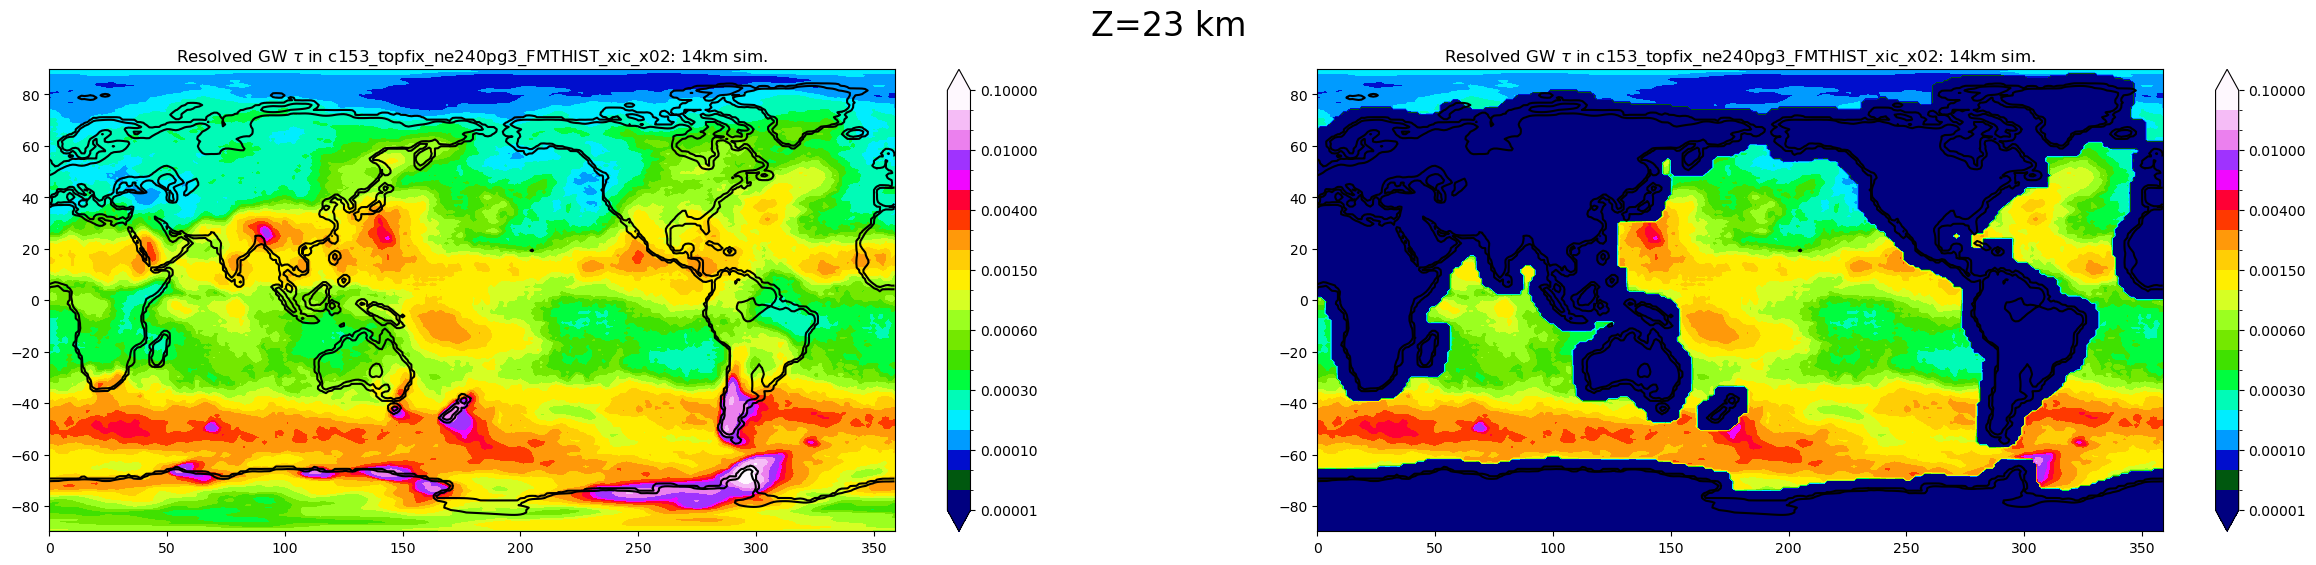

In [7]:

trunc_k, sigma=10, 4.5
#trunc_k, sigma=20, 7.5

htopo_sm = gaussian_filter(  htopo , sigma=sigma,
                           truncate=((trunc_k-1)/2)/sigma, mode="nearest")

mask=htopo_sm <= 1.0

z=np.argmin( np.abs( zlev - 23_000. ) )

title_ = f'Z={zlev[z]/1000.:.0f} km '     #        camsnap-yaaaa.h.2004-06-15-21600.nc'


#flev=[0.0001,0.0002,0.0005,  0.001,0.002,0.005,  0.01,0.02,0.05,  0.1,0.2,0.5,   1.0  ]
flev=[0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.2,0.5,   1.0  ]
flev=0.1*np.asarray( flev )
print(flev)
cmapN='gist_ncar'

cmap = plt.cm.bwr  #gist_ncar  # Or any other colormap
cmap = plt.cm.gist_ncar # .plasma #gist_ncar  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)

topocolor='white' #'black'
topocolor='black'


fig,axs=plt.subplots( 1, 2, figsize=(30,6) )

ax=axs[0]
c = ax.contourf( lon, lat, np.average(rho_epwp_1[:,z,:,:],axis=0) ,levels=flev, cmap=cmap , norm=norm, extend='both'  )
#c = ax.contourf( lon, lat, np.average(epwp_1[:,z,:,:],axis=0) ,levels=21, cmap=cmap , extend='both'  )
to = ax.contour( lon, lat, htopo, levels=[1,100] ,colors=topocolor)
ax.set_title( f'Resolved GW {r"$\tau$"} in {case1}: {reso} sim.')
plt.colorbar( c )

ax=axs[1]
c = ax.contourf( lon, lat, np.average(rho_epwp_1[:,z,:,:],axis=0) *mask,levels=flev, cmap=cmap , norm=norm, extend='both'  )
#c = ax.contourf( lon, lat, np.average(epwp_1[:,z,:,:],axis=0) ,levels=21, cmap=cmap , extend='both'  )
to = ax.contour( lon, lat, htopo, levels=[1,100] ,colors=topocolor)
ax.set_title( f'Resolved GW {r"$\tau$"} in {case1}: {reso} sim.')
plt.colorbar( c )

"""
ax=axs[1]
c = ax.contourf( lon, lat, np.average(rho_epwp_2[:,z,:,:],axis=0) ,levels=flev, cmap=cmap , norm=norm, extend='both'  )
to = ax.contour( lon, lat, htopo, levels=[1,100] ,colors=topocolor)
ax.set_title( f'Resolved GW {r"$\tau$"} in {case2}: {reso} sim.')
plt.colorbar( c )
"""
plt.suptitle( title_ , fontsize=24) 

print(X1.lev[z].values)
print(zlev[z])


In [44]:
z0,lat0,lon0 =23_000., -50. , 30. 
z_event  = np.argmin( np.abs( zlev - z0 ) ) 
print( zlev[ z_event ] )

event_list=[]

for t in np.arange( nt ):
    #events  = auti.find_gw_events(epwp= rho_epwp_1[t,z,:,:] , thresh=0.01, connectivity=8)
    events = auti.find_gw_events_watershed(epwp= rho_epwp_1[t,z,:,:] , thresh=0.02 )  #, thresh=0.01, connectivity=8)
    event_list.append( events )

# Not useful in current form
#tracks = auti.track_events(event_lists=event_list , max_dist=5)

22872.906006759255


In [60]:
print( len(event_list[1]) )

17


[1.0e-05 2.0e-05 5.0e-05 1.0e-04 1.5e-04 2.0e-04 3.0e-04 4.0e-04 5.0e-04
 6.0e-04 8.0e-04 1.0e-03 1.5e-03 2.0e-03 3.0e-03 4.0e-03 5.0e-03 6.0e-03
 1.0e-02 2.0e-02 5.0e-02 1.0e-01]
38.09935214868368
22872.906006759255


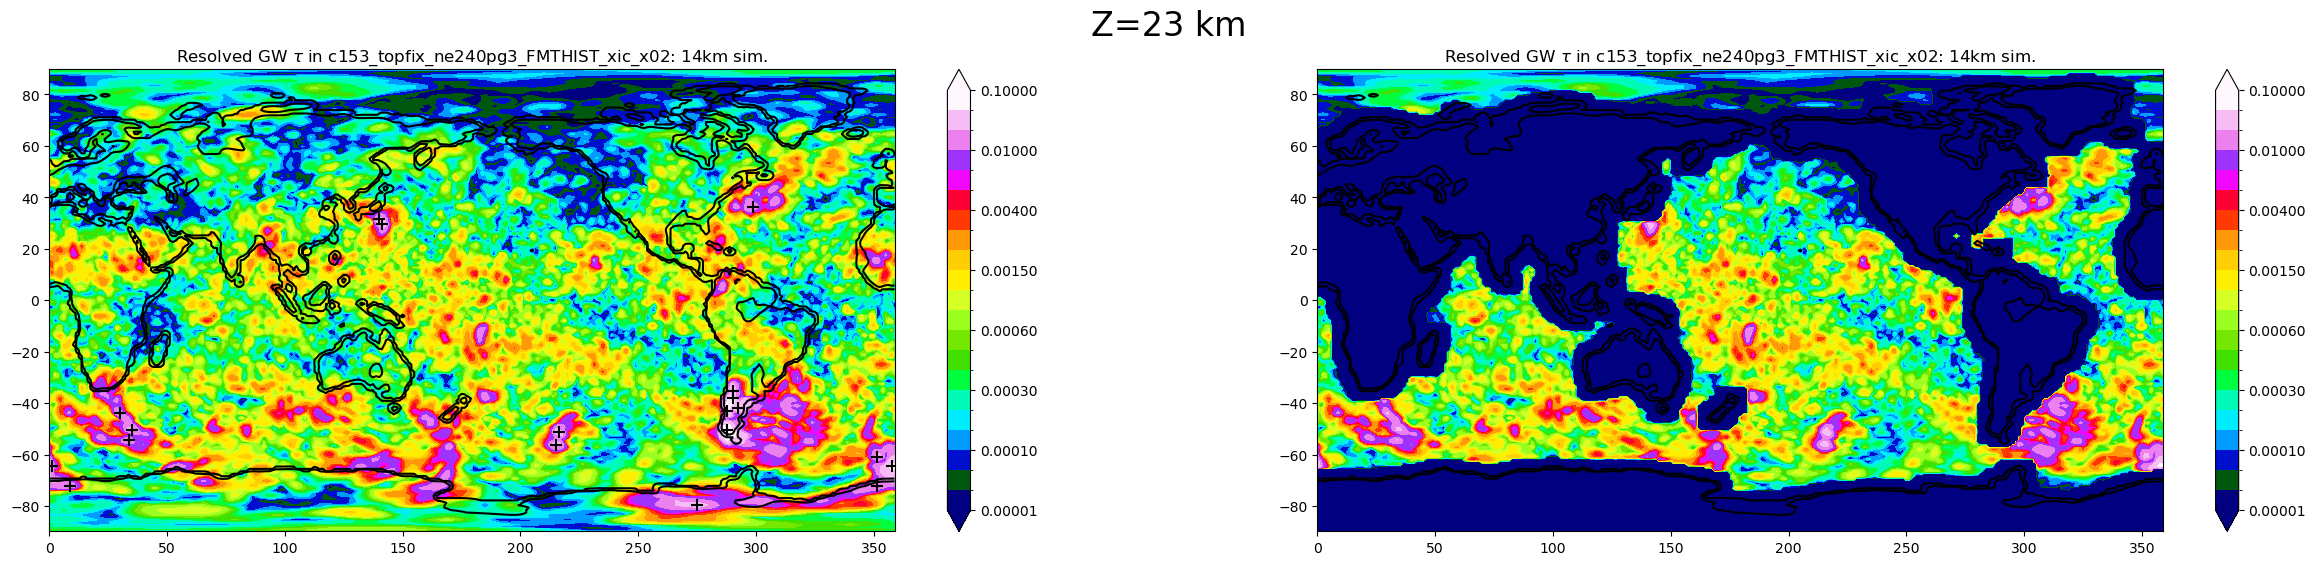

In [9]:
######################################################
# Checks events found for a particular time 
######################################################
t0=10
iy2 = [ev["iy"] for ev in event_list[t0] ]
ix2 = [ev["ix"] for ev in event_list[t0] ]

trunc_k, sigma=10, 4.5
#trunc_k, sigma=20, 7.5

htopo_sm = gaussian_filter(  htopo , sigma=sigma,
                           truncate=((trunc_k-1)/2)/sigma, mode="nearest")

mask=htopo_sm <= 1.0

z=np.argmin( np.abs( zlev - 23_000. ) )

title_ = f'Z={zlev[z]/1000.:.0f} km '     #        camsnap-yaaaa.h.2004-06-15-21600.nc'


#flev=[0.0001,0.0002,0.0005,  0.001,0.002,0.005,  0.01,0.02,0.05,  0.1,0.2,0.5,   1.0  ]
flev=[0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.2,0.5,   1.0  ]
flev=0.1*np.asarray( flev )
print(flev)
cmapN='gist_ncar'

cmap = plt.cm.bwr  #gist_ncar  # Or any other colormap
cmap = plt.cm.gist_ncar # .plasma #gist_ncar  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)

topocolor='white' #'black'
topocolor='black'


fig,axs=plt.subplots( 1, 2, figsize=(30,6) )

t=t0

ax=axs[0]
c = ax.contourf( lon, lat, rho_epwp_1[t,z,:,:]  ,levels=flev, cmap=cmap , norm=norm, extend='both'  )
to = ax.contour( lon, lat, htopo, levels=[1,100] ,colors=topocolor)
eve2 = ax.scatter( lon[ix2] , lat[iy2], color='black', marker='+', s=80)


ax.set_title( f'Resolved GW {r"$\tau$"} in {case1}: {reso} sim.')
plt.colorbar( c )

ax=axs[1]
c = ax.contourf( lon, lat, rho_epwp_1[t,z,:,:]*mask,levels=flev, cmap=cmap , norm=norm, extend='both'  )
#c = ax.contourf( lon, lat, np.average(epwp_1[:,z,:,:],axis=0) ,levels=21, cmap=cmap , extend='both'  )
to = ax.contour( lon, lat, htopo, levels=[1,100] ,colors=topocolor)
ax.set_title( f'Resolved GW {r"$\tau$"} in {case1}: {reso} sim.')
plt.colorbar( c )

"""
ax=axs[1]
c = ax.contourf( lon, lat, np.average(rho_epwp_2[:,z,:,:],axis=0) ,levels=flev, cmap=cmap , norm=norm, extend='both'  )
to = ax.contour( lon, lat, htopo, levels=[1,100] ,colors=topocolor)
ax.set_title( f'Resolved GW {r"$\tau$"} in {case2}: {reso} sim.')
plt.colorbar( c )
"""
plt.suptitle( title_ , fontsize=24) 

print(X1.lev[z].values)
print(zlev[z])


In [61]:
count=0
for evs in event_list:
    for ev in evs:
        lat0=lat[ ev['iy'] ]
        lon0=lon[ ev['ix'] ]
        if (lat0>=-60) and (lat0<=-40.) and (lon0 >= 0.) and (lon0 <= 60.):
            count=count+1

print( count )

u_comp = np.zeros(( count, nz ))
v_comp = np.zeros(( count, nz ))
zeta_comp = np.zeros(( count, nz ))
epwp_comp = np.zeros(( count, nz ))
time_ev = np.zeros(( count ))
iy_ev = np.zeros(( count ))
ix_ev = np.zeros(( count ))


c,t=0,0
for evs in event_list:
    for ev in evs:
        lat0=lat[ ev['iy'] ]
        lon0=lon[ ev['ix'] ]
        if (lat0>=-60) and (lat0<=-40.) and (lon0 >= 0.) and (lon0 <= 60.):
            epwp_comp[c,:] = rho_epwp_1[t,:, ev['iy'], ev['ix'] ]
            u_comp[c,:] = u_1[t,:, ev['iy'], ev['ix'] ]
            zeta_comp[c,:] = zeta_1[t,:, ev['iy'], ev['ix'] ]
            time_ev[c] = t
            iy_ev[c],ix_ev[c] = ev['iy'], ev['ix']
            c=c+1
    t=t+1

print( c )

181
181


In [73]:
importlib.reload( auti )


<module 'analysis_utils' from '/glade/work/juliob/HiRes_ana_dev/Drivers/Analysis/analysis_utils.py'>

In [74]:
yak=auti.composite4D( event_list=event_list, aa=zeta_1 , lon=lon, lat=lat, window=[5,5,5] , TZHkey='tzyx', lat_range=[-60,-40], lon_range=[0,60] )

181


In [75]:
yak.shape

(181, 6, 93, 11, 11)

In [11]:
print( poopypants )

NameError: name 'poopypants' is not defined

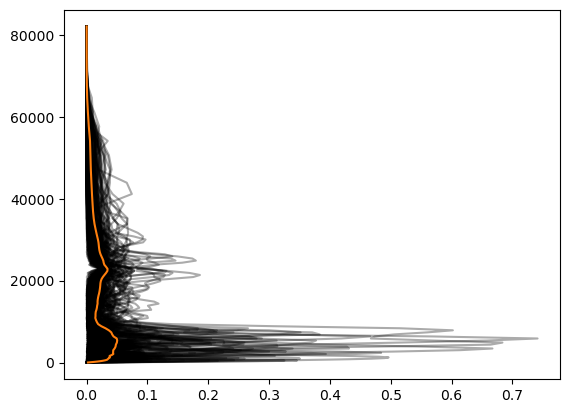

In [12]:
plt.plot( np.mean( epwp_comp, axis=0 ), zlev )
for n in np.arange( count ):
    plt.plot( epwp_comp[n,:] , zlev, color='black' , alpha=.33 )

plt.plot( np.mean( epwp_comp, axis=0 ), zlev )



(0.0, 20000.0)

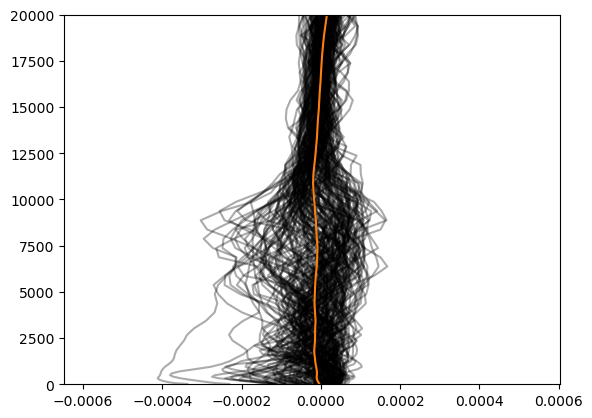

In [13]:
plt.plot( np.mean( zeta_comp, axis=0 ), zlev )
for n in np.arange( count ):
    plt.plot( zeta_comp[n,:] , zlev, color='black' , alpha=.33 )

plt.plot( np.mean( zeta_comp, axis=0 ), zlev )

#plt.xlim(0.,.3)
plt.ylim(0.,20000.)


time = 8.0, lat = -47.59162303664919, lon = 20.0 


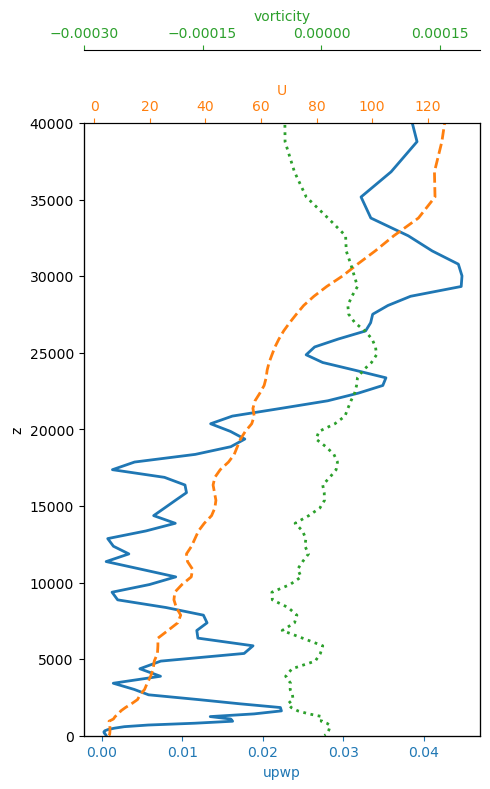

In [29]:
from matplotlib.ticker import MaxNLocator

n=3


print( f"time = {time_ev[n]}, lat = {lat[int(iy_ev[n])]}, lon = {lon[int(ix_ev[n])]} " )
epwp,vort,U,zl = epwp_comp[n,:],zeta_comp[n,:], u_comp[n,:], zlev
fig, ax1 = plt.subplots(figsize=(5, 8))

# First variable: upwp
ax1.plot(epwp, zl, color='tab:blue', linewidth=2)
ax1.set_xlabel("upwp", color='tab:blue')
ax1.tick_params(axis='x', colors='tab:blue')
ax1.set_ylabel("z")
ax1.set_ylim(0,40_000.)

# Second variable: U
ax2 = ax1.twiny()
ax2.plot(U, zl, color='tab:orange', linewidth=2, linestyle='--')
ax2.set_xlabel("U", color='tab:orange')
ax2.tick_params(axis='x', colors='tab:orange')

# Third variable: vorticity
ax3 = ax1.twiny()
ax3.spines["top"].set_position(("axes", 1.12))   # move this x-axis upward
ax3.plot(vort, zl, color='tab:green', linewidth=2, linestyle=':')
ax3.set_xlabel("vorticity", color='tab:green')
ax3.tick_params(axis='x', colors='tab:green')
ax3.set_xlim(-0.0003,0.0002 )
ax3.xaxis.set_major_locator(MaxNLocator(4))
# Optional: if pressure or model level increases downward
# ax1.invert_yaxis()

plt.tight_layout()


[1.0e-05 2.0e-05 5.0e-05 1.0e-04 1.5e-04 2.0e-04 3.0e-04 4.0e-04 5.0e-04
 6.0e-04 8.0e-04 1.0e-03 1.5e-03 2.0e-03 3.0e-03 4.0e-03 5.0e-03 6.0e-03
 1.0e-02 2.0e-02 5.0e-02 1.0e-01]
time = 8.0, lat = -47.59162303664919, lon = 20.0 


'\n# First variable: upwp\nax1.plot(epwp, zl, color=\'tab:blue\', linewidth=2)\nax1.set_xlabel("upwp", color=\'tab:blue\')\nax1.tick_params(axis=\'x\', colors=\'tab:blue\')\nax1.set_ylabel("z")\nax1.set_ylim(0,40_000.)\n\n# Second variable: U\nax2 = ax1.twiny()\nax2.plot(U, zl, color=\'tab:orange\', linewidth=2, linestyle=\'--\')\nax2.set_xlabel("U", color=\'tab:orange\')\nax2.tick_params(axis=\'x\', colors=\'tab:orange\')\n\n# Third variable: vorticity\nax3 = ax1.twiny()\nax3.spines["top"].set_position(("axes", 1.12))   # move this x-axis upward\nax3.plot(vort, zl, color=\'tab:green\', linewidth=2, linestyle=\':\')\nax3.set_xlabel("vorticity", color=\'tab:green\')\nax3.tick_params(axis=\'x\', colors=\'tab:green\')\nax3.set_xlim(-0.0003,0.0002 )\nax3.xaxis.set_major_locator(MaxNLocator(4))\n# Optional: if pressure or model level increases downward\n# ax1.invert_yaxis()\n\nplt.tight_layout()\n'

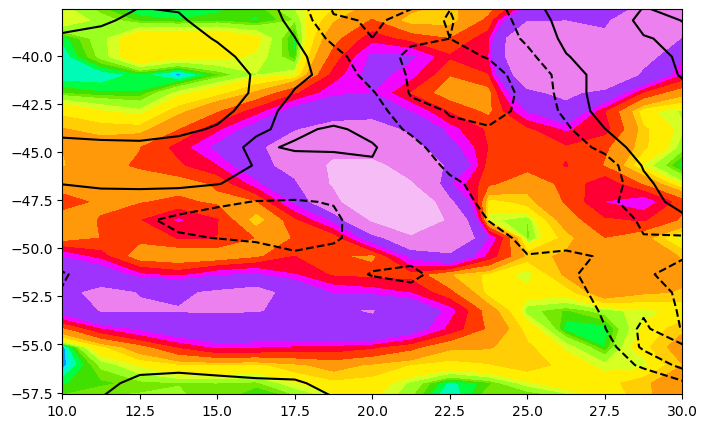

In [39]:
from matplotlib.ticker import MaxNLocator



flev=[0.0001,0.0002,0.0005,  0.001,0.0015,0.002,0.003,0.004,0.005,0.006,0.008,    0.01,0.015,0.02,0.03,0.04,0.05,0.06,  0.1,0.2,0.5,   1.0  ]
flev=0.1*np.asarray( flev )
print(flev)
cmapN='gist_ncar'

cmap = plt.cm.bwr  #gist_ncar  # Or any other colormap
cmap = plt.cm.gist_ncar # .plasma #gist_ncar  #gist_ncar  # Or any other colormap
norm = mcolors.BoundaryNorm(boundaries=flev, ncolors=cmap.N, clip=False)



n=3


print( f"time = {time_ev[n]}, lat = {lat[int(iy_ev[n])]}, lon = {lon[int(ix_ev[n])]} " )
lat_0 = lat[int(iy_ev[n])] 
lon_0 = lon[int(ix_ev[n])]
t_0 = int(time_ev[n])

t,z=t_0,z_event
zvo = np.argmin( np.abs( zlev - 10_000. ) ) 

fig, ax = plt.subplots(figsize=(8, 5))
c = ax.contourf( lon, lat, rho_epwp_1[t,z,:,:] ,levels=flev, cmap=cmap , norm=norm, extend='both'  )
zoo = ax.contour( lon, lat, zeta_1[t-0,zvo,:,:] ,levels=21, colors='black' )
#c = ax.contourf( lon, lat, np.average(epwp_1[:,z,:,:],axis=0) ,levels=21, cmap=cmap , extend='both'  )
to = ax.contour( lon, lat, htopo, levels=[1,100] ,colors=topocolor)

#ax.set_xlim( 0,30 )
#ax.set_ylim( -55,-35 )


ax.set_xlim( np.asarray( [lon_0-10., lon_0+10.] ) )
ax.set_ylim( np.asarray( [lat_0-10., lat_0+10.] ) )

"""
# First variable: upwp
ax1.plot(epwp, zl, color='tab:blue', linewidth=2)
ax1.set_xlabel("upwp", color='tab:blue')
ax1.tick_params(axis='x', colors='tab:blue')
ax1.set_ylabel("z")
ax1.set_ylim(0,40_000.)

# Second variable: U
ax2 = ax1.twiny()
ax2.plot(U, zl, color='tab:orange', linewidth=2, linestyle='--')
ax2.set_xlabel("U", color='tab:orange')
ax2.tick_params(axis='x', colors='tab:orange')

# Third variable: vorticity
ax3 = ax1.twiny()
ax3.spines["top"].set_position(("axes", 1.12))   # move this x-axis upward
ax3.plot(vort, zl, color='tab:green', linewidth=2, linestyle=':')
ax3.set_xlabel("vorticity", color='tab:green')
ax3.tick_params(axis='x', colors='tab:green')
ax3.set_xlim(-0.0003,0.0002 )
ax3.xaxis.set_major_locator(MaxNLocator(4))
# Optional: if pressure or model level increases downward
# ax1.invert_yaxis()

plt.tight_layout()
"""

In [ ]:
# Pick locatio and time for a sample plot. he values below were picked for ne240 x02 i.e., Aug 2004

z0,lat0,lon0 =25_000., 12. , 250. 
z0,lat0,lon0 =25_000., -50. , 130. 
z0,lat0,lon0 =25_000., -50. , 30. 
#z0,lat0,lon0 =25_000., -12. , 180. 

t,z,y,x = 43, np.argmin( np.abs( zlev - z0 ) ) , np.argmin( np.abs( lat - lat0 ) ) , np.argmin( np.abs( lon - lon0 ) )


In [ ]:
plt.plot( rho_epwp_1[:,z,y,x] )
plt.xlim(40,50)

In [ ]:

t=43

In [ ]:

plt.plot( np.average(rho_epwp_1[:,:,y,x],axis=0) , zlev )
#plt.plot( np.average(rho_epwp_2[:,1:,y,x],axis=0) , zlev )
#plt.xlim(0,0.01)


In [ ]:
plt.contourf( lat, zlev, np.mean( np.mean( u_1 , axis=3) ,0) )
plt.colorbar()

In [ ]:
nt,nz,ny,nx = np.shape( u_1 )
zeta_1 = np.zeros( ( nt,nz,ny,nx) )

for t in np.arange( nt ):
    for z in np.arange( nz ):
        zeta_1[t,z,:,:] = nuti.Sphere_Curl2( f_x=u_1[t,z,:,:]  , f_y=v_1[t,z,:,:] , lat=lat, lon=lon , wrap=True, verbose=False)


In [ ]:
from matplotlib.ticker import MaxNLocator

epwp,vort,U,zl = rho_epwp_1[t,:,y,x] , zeta_1[t,:,y,x] , u_1[t,:,y,x], zlev
fig, ax1 = plt.subplots(figsize=(5, 8))

# First variable: upwp
ax1.plot(epwp, zl, color='tab:blue', linewidth=2)
ax1.set_xlabel("upwp", color='tab:blue')
ax1.tick_params(axis='x', colors='tab:blue')
ax1.set_ylabel("z")
ax1.set_ylim(0,40_000.)

# Second variable: U
ax2 = ax1.twiny()
ax2.plot(U, zl, color='tab:orange', linewidth=2, linestyle='--')
ax2.set_xlabel("U", color='tab:orange')
ax2.tick_params(axis='x', colors='tab:orange')

# Third variable: vorticity
ax3 = ax1.twiny()
ax3.spines["top"].set_position(("axes", 1.12))   # move this x-axis upward
ax3.plot(vort, zl, color='tab:green', linewidth=2, linestyle=':')
ax3.set_xlabel("vorticity", color='tab:green')
ax3.tick_params(axis='x', colors='tab:green')
ax3.set_xlim(-0.0003,0.0002 )
ax3.xaxis.set_major_locator(MaxNLocator(4))
# Optional: if pressure or model level increases downward
# ax1.invert_yaxis()

plt.tight_layout()


In [ ]:
len(event_list)

In [ ]:
evo=event_list[100]

In [ ]:
len(evo)

In [ ]:
evo[10]

In [ ]:
print( count )

In [ ]:
u_comp = np.zeros(( count, nz ))
v_comp = np.zeros(( count, nz ))
zeta_comp = np.zeros(( count, nz ))
epwp_comp = np.zeros(( count, nz ))


c,t=0,0
for evs in event_list:
    for ev in evs:
        lat0=lat[ ev['iy'] ]
        lon0=lon[ ev['ix'] ]
        #if (lat0>=-60) and (lat0<=-40.) and (lon0 <= 50.):
        if (lat0>=-60) and (lat0<=-40.) and (lon0 >= 190.) and (lon0 <= 270.):
            epwp_comp[c,:] = rho_epwp_1[t,:, ev['iy'], ev['ix'] ]
            u_comp[c,:] = u_1[t,:, ev['iy'], ev['ix'] ]
            zeta_comp[c,:] = zeta_1[t,:, ev['iy'], ev['ix'] ]
            c=c+1
    t=t+1

In [ ]:
plt.plot( np.mean( zeta_comp, axis=0 ), zlev )
for c in np.arange( count ):
    plt.plot( zeta_comp[c,:] , zlev, color='black' , alpha=.33 )

plt.plot( np.mean( zeta_comp, axis=0 ), zlev )

#plt.xlim(0.,.3)
plt.ylim(0.,20000.)


In [ ]:
plt.plot( np.mean( u_comp, axis=0 ), zlev )
for c in np.arange( count ):
    plt.plot( u_comp[c,:] , zlev, color='black' , alpha=.33 )

plt.plot( np.mean( u_comp, axis=0 ), zlev )
plt.ylim(0.,20000.)

#plt.xlim(0.,.3)

In [ ]:
#plt.xlim(0.,.02)